# Technical Assessment 5

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://github.com/NadavKiani/Students-Performance-in-Exams/raw/master/StudentsPerformance.csv"
df = pd.read_csv(url)


df['School_Support'] = df['test preparation course'].map({'none': 'No', 'completed': 'Yes'})

df['Final_Grade'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

np.random.seed(42) 
df['Study_Hours'] = np.clip((df['Final_Grade'] / 10) + np.random.uniform(-2, 2, len(df)), 1, 10)

df['Attendance_Rate'] = np.clip((df['Final_Grade'] * 0.8) + 20 + np.random.uniform(-10, 10, len(df)), 50, 100)

## Part A

In [8]:
print("--- First 5 Rows ---")
display(df.head())

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Basic Statistics ---")
display(df.describe())

--- First 5 Rows ---


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,School_Support,Final_Grade,Study_Hours,Attendance_Rate
0,female,group B,bachelor's degree,standard,none,72,72,74,No,72.666667,6.764827,71.835992
1,female,group C,some college,standard,completed,69,90,88,Yes,82.333333,10.000000,86.704686
2,female,group B,master's degree,standard,none,90,95,93,No,92.666667,10.000000,100.000000
3,male,group A,associate's degree,free/reduced,none,47,57,44,No,49.333333,5.327967,64.111164
4,male,group C,some college,standard,none,76,78,75,No,76.333333,6.257408,87.197890



--- Column Names ---
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score', 'School_Support', 'Final_Grade', 'Study_Hours', 'Attendance_Rate']

--- Basic Statistics ---


,math score,reading score,writing score,Final_Grade,Study_Hours,Attendance_Rate
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667,6.727268,74.455559
std,15.16308,14.600192,15.195657,14.257326,1.769191,12.035994
min,0.00000,17.000000,10.000000,9.000000,1.000000,50.000000
25%,57.00000,59.000000,57.750000,58.333333,5.459546,65.852959
50%,66.00000,70.000000,69.000000,68.333333,6.876232,74.494330
75%,77.00000,79.000000,79.000000,77.666667,8.034028,82.978138
max,100.00000,100.000000,100.000000,100.000000,10.000000,100.000000


## Part B

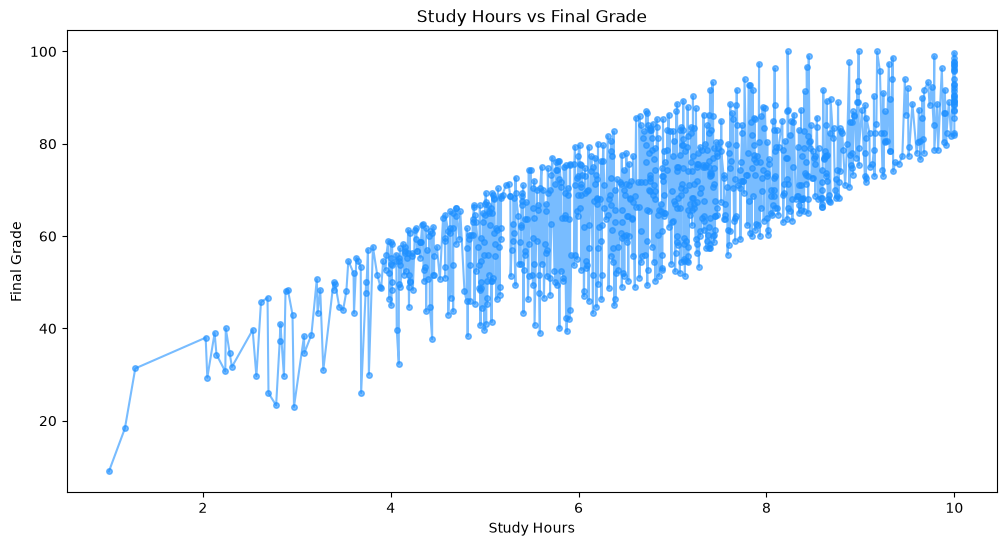

In [9]:
df_sorted_study = df.sort_values(by='Study_Hours')

plt.figure(figsize=(12, 6))
plt.plot(df_sorted_study['Study_Hours'].values, df_sorted_study['Final_Grade'].values, marker='o', linestyle='-', color='dodgerblue', alpha=0.6, markersize=4)
plt.xlabel('Study Hours')
plt.ylabel('Final Grade')
plt.title('Study Hours vs Final Grade')
plt.show()

## Part C

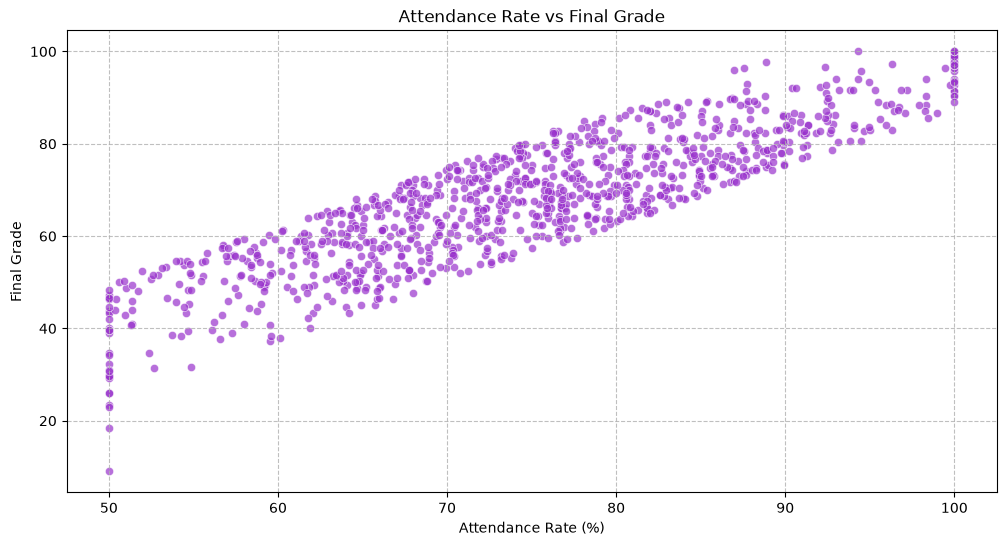

In [10]:
plt.figure(figsize=(12, 6))

plt.scatter(df['Attendance_Rate'], df['Final_Grade'], s=35, alpha=0.7, color='darkorchid', edgecolor='white', linewidth=0.5)

plt.xlabel('Attendance Rate (%)')
plt.ylabel('Final Grade')
plt.title('Attendance Rate vs Final Grade')
plt.grid(True, linestyle='--', alpha=0.8)
plt.show()

## Part D

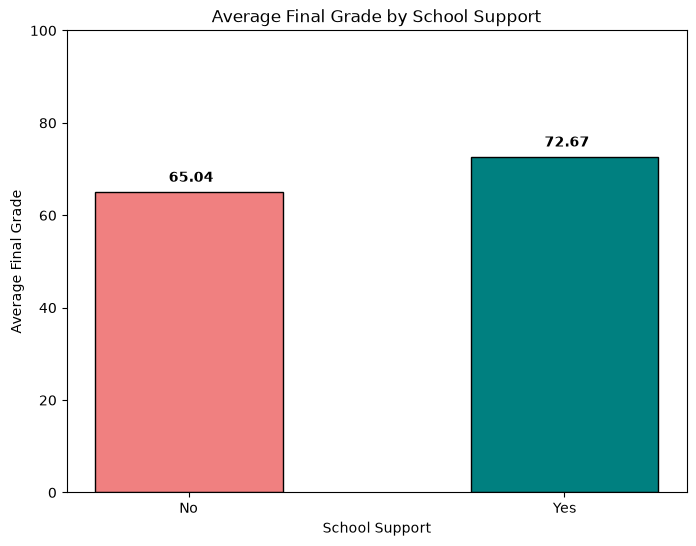

In [13]:
support_avg = df.groupby('School_Support')['Final_Grade'].mean()

plt.figure(figsize=(8, 6))
bars = plt.bar(support_avg.index, support_avg.values, color=['lightcoral', 'teal'], edgecolor='black', width=0.5)

plt.xlabel('School Support')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade by School Support')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval: .2f}", ha='center', va='bottom', fontweight='bold')

plt.show()

## Part E

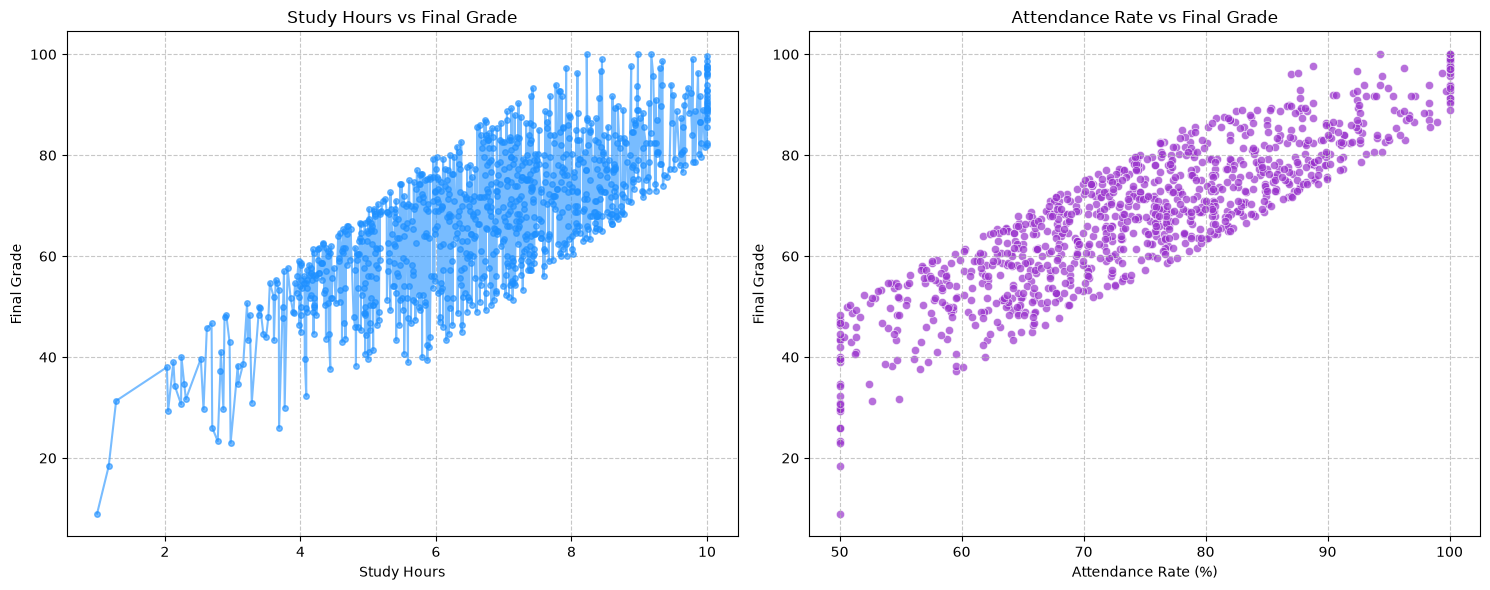

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(df_sorted_study['Study_Hours'].values, df_sorted_study['Final_Grade'].values, marker='o', linestyle='-', color='dodgerblue', alpha=0.6, markersize=4)
ax1.set_xlabel('Study Hours')
ax1.set_ylabel('Final Grade')
ax1.set_title('Study Hours vs Final Grade')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.scatter(df['Attendance_Rate'], df['Final_Grade'], s=35, alpha=0.7, color='darkorchid', edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Attendance Rate (%)')
ax2.set_ylabel('Final Grade')
ax2.set_title('Attendance Rate vs Final Grade')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Part F

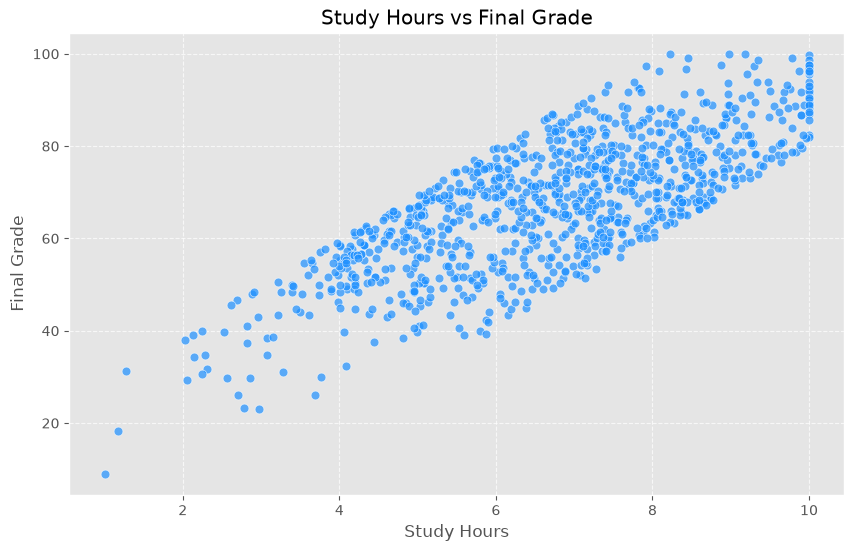

In [15]:
plt.style.use('ggplot')

plt.figure(figsize=(10, 6))
plt.scatter(df['Study_Hours'], df['Final_Grade'], s=40, alpha=0.7, color='dodgerblue', edgecolor='white', linewidth=0.5)
plt.xlabel('Study Hours')
plt.ylabel('Final Grade')
plt.title('Study Hours vs Final Grade')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()